<a href="https://colab.research.google.com/github/Sanjubana/sanjay_singh_jecrc/blob/main/week_5_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [25]:
text = """
Deep learning is a subset of machine learning.
Machine learning helps computers learn from data.
Artificial intelligence is transforming the world.
"""

text = text.lower()

In [26]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1
print(f"Vocabulary Size: {total_words}")

input_sequences = []

for line in text.split('.'):
    line = line.strip()
    if not line:
     continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
      n_gram = token_list[:i + 1]
      input_sequences.append(n_gram)

print(f"Total N-gram sequences: {len(input_sequences)}")

max_len = max(len(x) for x in input_sequences)
print(f"Max sequence length: {max_len}")

input_sequences = np.array(
 pad_sequences(input_sequences, maxlen=max_len, padding='pre')
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Vocabulary Size: 18
Total N-gram sequences: 18
Max sequence length: 8
X shape: (18, 7)
y shape: (18, 18)


In [27]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
], name="Vanilla_RNN")

rnn_model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
  )

rnn_model.summary()

early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)

history_rnn = rnn_model.fit(X, y, epochs=200, verbose=0, callbacks=[early_stop])

print(f"Stopped at epoch : {len(history_rnn.history['loss'])}")
print(f"Final Loss       : {history_rnn.history['loss'][-1]:.4f}")
print(f"Final Accuracy   : {history_rnn.history['accuracy'][-1]*100:.2f}%")


Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch : 200
Final Loss       : 0.0040
Final Accuracy   : 100.00%


In [28]:
lstm_model = Sequential([
  Embedding(total_words, 64, input_length=max_len - 1),
  LSTM(128),
  Dense(total_words, activation='softmax')
  ], name="LSTM_Model")

lstm_model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

lstm_model.summary()

early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)

history_lstm = lstm_model.fit(X, y, epochs=200, verbose=0, callbacks=[early_stop])

print(f"Stopped at epoch : {len(history_lstm.history['loss'])}")
print(f"Final Loss       : {history_lstm.history['loss'][-1]:.4f}")
print(f"Final Accuracy   : {history_lstm.history['accuracy'][-1]*100:.2f}%")


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch : 200
Final Loss       : 0.0186
Final Accuracy   : 100.00%


In [29]:
gru_model = Sequential([
  Embedding(total_words, 64, input_length=max_len - 1),
  GRU(128),
  Dense(total_words, activation='softmax')
], name="GRU_Model")

gru_model.compile(
   loss='categorical_crossentropy',
   optimizer='adam',
   metrics=['accuracy']
)

gru_model.summary()

early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)

history_gru = gru_model.fit(X, y, epochs=200, verbose=0, callbacks=[early_stop])

print(f"Stopped at epoch : {len(history_gru.history['loss'])}")
print(f"Final Loss       : {history_gru.history['loss'][-1]:.4f}")
print(f"Final Accuracy   : {history_gru.history['accuracy'][-1]*100:.2f}%")


Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch : 200
Final Loss       : 0.0053
Final Accuracy   : 100.00%


In [30]:
def generate_text(model, seed_text, next_words):
      result = seed_text

      for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences(
          [token_list], maxlen=max_len - 1, padding='pre'
        )

        predicted_index = np.argmax(
           model.predict(token_list, verbose=0), axis=-1
        )[0]

        for word, index in tokenizer.word_index.items():
          if index == predicted_index:
             result += " " + word
             break

        return result

print("generate_text() function ready.")

generate_text() function ready.


In [31]:
seed = "machine"
n_words = 6

print("=" * 55)
print(f"  Seed: '{seed}'  |  Generating {n_words} words")
print("=" * 55)
print(f"  RNN  → {generate_text(rnn_model,  seed, n_words)}")
print(f"  LSTM → {generate_text(lstm_model, seed, n_words)}")
print(f"  GRU  → {generate_text(gru_model,  seed, n_words)}")

print("\n  --- Additional Seeds ---")
for phrase in ["deep learning", "artificial", "neural"]:
    print(f"\n  Seed: '{phrase}'")
    print(f"    RNN  → {generate_text(rnn_model,  phrase, 5)}")
    print(f"    LSTM → {generate_text(lstm_model, phrase, 5)}")
    print(f"    GRU  → {generate_text(gru_model,  phrase, 5)}")

  Seed: 'machine'  |  Generating 6 words
  RNN  → machine learning
  LSTM → machine learning
  GRU  → machine learning

  --- Additional Seeds ---

  Seed: 'deep learning'
    RNN  → deep learning is
    LSTM → deep learning is
    GRU  → deep learning is

  Seed: 'artificial'
    RNN  → artificial intelligence
    LSTM → artificial intelligence
    GRU  → artificial intelligence

  Seed: 'neural'
    RNN  → neural learning
    LSTM → neural learning
    GRU  → neural learning


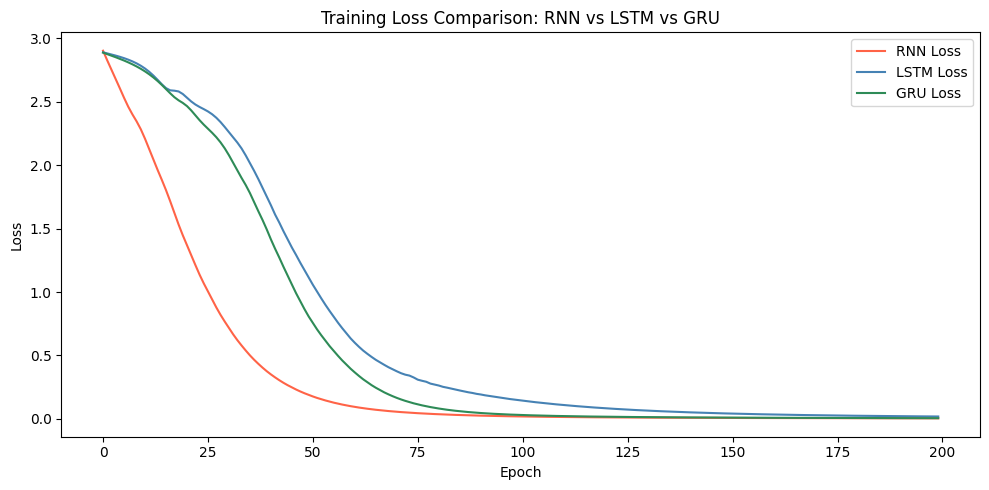

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['loss'],  label='RNN Loss',  color='tomato')
plt.plot(history_lstm.history['loss'], label='LSTM Loss', color='steelblue')
plt.plot(history_gru.history['loss'],  label='GRU Loss',  color='seagreen')
plt.title('Training Loss Comparison: RNN vs LSTM vs GRU')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()